In [1]:
import pysam
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import pickle
import numpy as np
import matplotlib
import pandas as pd
import re
from collections import Counter
import itertools
import pylab
import sympy as sy
from scipy.stats import chi2_contingency

# 0. prepare for plot

In [7]:
#read all sample FFPE
allSample = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/allSample.06.12.23/TCSIntegrationList.txt'
# with open(allSample) as inputFile:
#     rows = inputFile.read().split('\n')
    

In [8]:
allSample = pd.read_csv(allSample,header=None)
allSample.columns = ['Sample','Chro','Site','HPVSite','Conf']


In [9]:
allSample[allSample['Sample'] == 'Sample_2789-CB-85']

,Sample,Chro,Site,HPVSite,Conf
0,Sample_2789-CB-85,3,169630796,2877;,high;
1,Sample_2789-CB-85,5,122202248,916;,low;
2,Sample_2789-CB-85,3,169496784,1894;,high;


In [10]:
allSample

,Sample,Chro,Site,HPVSite,Conf
0,Sample_2789-CB-85,3,169630796,2877;,high;
1,Sample_2789-CB-85,5,122202248,916;,low;
2,Sample_2789-CB-85,3,169496784,1894;,high;
3,Sample_6670-CB-74,8,80627698,4200;,low;
4,Sample_2920-CB-93,10,111201046,1364;,low;
...,...,...,...,...,...
4993,Sample_2655-CB-55,3,93470647,4758;3887;,low;low;
4994,Sample_2655-CB-55,11,119049438,3419;,low;
4995,Sample_2655-CB-55,3,192694856,1397;,low;
4996,Sample_2655-CB-55,11,129226351,3941;,low;


In [11]:
len(set(allSample['Sample']))

181

In [12]:
181-23

158

In [13]:
len(allSample)

4998

In [14]:
4998-545

4453

In [15]:
#read all sample LR
allSampleLR = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/allSample.01.25.23/TCSIntegrationList_CL.txt'
allSampleLR = pd.read_csv(allSampleLR,header=None)
allSampleLR.columns = ['Sample','Chro','Site']
#read all sample tissue
allSampleTissue = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/allSample.09.11.23/TCSIntegrationList_Tissue.txt'
allSampleTissue = pd.read_csv(allSampleTissue,header=None)
allSampleTissue.columns = ['Sample','Chro','Site']

In [16]:
len(set(allSampleTissue['Sample']))

6

In [17]:
len(set(allSampleLR['Sample']))

9

In [18]:
len(allSample) + len(allSampleLR) + len(allSampleTissue)

5310

In [19]:
len(allSampleLR) + len(allSampleTissue)

312

In [20]:
dupCL = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/sampleWithDuplications.09.11.23/TCSIntegrationList_dup_CL.csv'


In [21]:
dupTissue = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/sampleWithDuplications.09.11.23/TCSIntegrationList_dup_Tissue.csv'


In [66]:
ffep = '../sup_1/TCSIntegrationList_dup_sup1.csv'

In [23]:
!head /home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/sampleWithDuplications.09.11.23/TCSIntegrationList_dup_CL.csv


In [24]:
CLdf = pd.read_csv(dupCL)

In [25]:
Tissuedf = pd.read_csv(dupTissue)

In [26]:
CLdf

,SampleID,SeqID,Chro,Ins,SPCov,hpvIns,Conf,numIns,GeneFallInto,GeneWithin50k
0,2655-CB-91,Sample_2655-CB-91,9,97813335,23.171433,680;680;,high;low;,14,PTCSC2,FOXE1;PTCSC2
1,2655-CB-91,Sample_2655-CB-91,9,97814224,0.048476,680;,low;,14,PTCSC2,FOXE1;PTCSC2
2,2655-CB-91,Sample_2655-CB-91,9,97833766,4.653677,1309;,high;,14,PTCSC2,FOXE1;PTCSC2
3,2655-CB-91,Sample_2655-CB-91,9,97857784,2.811596,821;,high;,14,NaN,FOXE1;PTCSC2;TRMO
4,2655-CB-91,Sample_2655-CB-91,9,97860564,1.163419,3922;,high;,14,NaN,FOXE1;PTCSC2;TRMO
...,...,...,...,...,...,...,...,...,...,...
129,6670-CB-86,Sample_6670-CB-86,9,107480080,0.057589,5976;,low;,11,NaN,LINC01509;HMGN2P32;RNU6-492P;KLF4
130,6670-CB-86,Sample_6670-CB-86,9,107481156,0.086384,33;,low;,11,NaN,LINC01509;HMGN2P32;RNU6-492P;KLF4
131,6670-CB-86,Sample_6670-CB-86,9,107483254,5.067845,4517;,high;,11,NaN,LINC01509;HMGN2P32;RNU6-492P;KLF4
132,6670-CB-86,Sample_6670-CB-86,9,107485110,1.065399,2935;,high;,11,KLF4,ENST00000454576;LINC01509;RNU6-492P;HMGN2P32;KLF4


In [67]:
ffepDf = pd.read_csv(ffep)

In [74]:
ffepDf

,SampleID,SeqID,Chro,Ins,SPCov,hpvIns,Conf,numIns,GeneFallInto,GeneWithin50k
0,2655-CB-78,Sample_2655-CB-78,11,59110346,0.306153,3077;,low;,9,FAM111B,ENST00000529891;ENST00000688864;GLYATL1B;FAM11...
1,2655-CB-78,Sample_2655-CB-78,11,59167526,0.229615,1538;,low;,9,NaN,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
2,2655-CB-78,Sample_2655-CB-78,11,59172823,0.382692,6022;,low;,9,DTX4,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
3,2655-CB-78,Sample_2655-CB-78,11,59173849,0.306153,2540;,low;,9,DTX4,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
4,2655-CB-78,Sample_2655-CB-78,11,59174615,0.153077,6719;,low;,9,DTX4,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
...,...,...,...,...,...,...,...,...,...,...
547,SOP-021,Sample_2920-CB-83,9,123319363,0.499898,1767;,high;,7,NaN,CRB2
548,SOP-021,Sample_2920-CB-83,9,123319477,0.514959,1767;,high;,7,NaN,CRB2
549,SOP-021,Sample_2920-CB-83,9,123357240,0.999796,5585;,low;,7,CRB2,DENND1A;MIR601;CRB2
550,SOP-074,Sample_2789-CB-85,3,169496784,0.705088,1894;,high;,2,MECOM,MECOM;MECOM-AS1;RPL22P1


In [75]:
len(ffepDf['SampleID']) + len(CLdf['SampleID']) + len(Tissuedf['SampleID'])

708

In [76]:
len(set(ffepDf['SampleID'])) + len(set(CLdf['SampleID'])) + len(set(Tissuedf['SampleID']))

78

In [35]:
#hum ref information
bamPath = '/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res/Sample_81279/alignment/alignment.RG.indelre.mkdup.sort.bam'
bam = pysam.AlignmentFile(bamPath,'rb')
chroms = list(bam.references[0:22]) + [bam.references[23]]+ [bam.references[24]]
chromsLengthDf = []
chromsLength = list(bam.lengths[0:22]) + [bam.lengths[23]] + [bam.lengths[24]]
i = 0
for each in chroms[0:22]:
    if each != 'X' and each!= 'Y':
        chromsLengthDf.append([int(each),chromsLength[i]])
    else:
        chromsLengthDf.append([each,chromsLength[i]])
    i+=1
    

In [36]:
chromsLengthDf = pd.DataFrame(chromsLengthDf)

In [37]:
chromsLengthDf

,0,1
0,1,248956422
1,10,133797422
2,11,135086622
3,12,133275309
4,13,114364328
5,14,107043718
6,15,101991189
7,16,90338345
8,17,83257441
9,18,80373285


In [38]:
chromsLength = chromsLengthDf.sort_values(0).values.tolist()

In [39]:
chromsLength.append(['X',bam.lengths[23]])
chromsLength.append(['Y',bam.lengths[24]])

In [40]:
chromsLength = [x[1] for x in chromsLength]

# 1. plot only for Type2 HPV16+ OPSCC

In [41]:
#check to make sure samples are overlap

In [1]:
sup_0 = pd.read_excel('../sup_1/Sup_table_0_all_samples_final.xlsx')

NameError: name 'pd' is not defined

In [58]:
plot_1_df = sup_0[(sup_0['HPV type '] == 'HPV16') & (sup_0['Site'] == 'OP') & (sup_0['HPV integration type']=='Type2')]

In [73]:
ffepDf['SampleID']

0      2655-CB-78
1      2655-CB-78
2      2655-CB-78
3      2655-CB-78
4      2655-CB-78
          ...    
547       SOP-021
548       SOP-021
549       SOP-021
550       SOP-074
551       SOP-074
Name: SampleID, Length: 552, dtype: object

In [80]:
#check if all samples in plot_1 included
plot_1_list = []
for sample in plot_1_df['SeqID_Tumor']:
    if 'Sample_' + str(sample) not in ffepDf['SeqID'].to_list():
        print(sample)
    else:
        plot_1_list.append('Sample_' + str(sample))

In [90]:
plot_1_info_df = ffepDf[ffepDf['SeqID'].isin(plot_1_list)].reset_index(drop=True)

In [154]:
#random color for HPV genes
#hpv gene site PDX
pave_hpvDic = {'E1': [['865', '2814']],
 'E2': [['2756', '3853']],
 'E5_ALPHA': [['3850', '4101']],
 'E6': [['104', '559']],
 'E7': [['562', '858']],
 'L1': [['5639', '7156']],
 'L2': [['4237', '5658']],
 'E1^E4': [['865', '880'], ['3358', '3620']],
 'URR': [['7157', '7906'], ['1', '103']]}
# hpvDic = {}
# for each in pave_hpvDic:
#     hpvDic[each] = []
#     for eachslot in pave_hpvDic[each]:
#         start = int(eachslot[0]) - 864
#         end = int(eachslot[1]) - 864
#         if start < 1:
#             start = start +7905
#         if end < 1:
#             end = end + 7905
#         hpvDic[each].append([start,end])
        
# #add hpvgene        
# hpvGeneCL = []
# for each in CLdf['hpvIns']:
#     geneList = ''
#     for hpvins in each.split(';'):
#         if hpvins != '':
#             flag = False
#             for gene in pave_hpvDic:
#                 for slot in pave_hpvDic[gene]:
#                     if int(hpvins) >= int(slot[0]) and int(hpvins) < int(slot[1]):
                        
#                         geneList += gene + ';'
#                         flag = True
#             if flag == False:
#                 geneList += 'Intergenic' + ';'
#     hpvGeneCL.append(geneList)
# #print(len(hpvGeneCL),len(CLdf))
# CLdf['hpvGene'] = hpvGeneCL

# #add hpvgene        
# hpvGeneTissue = []
# for each in Tissuedf['hpvIns']:
#     geneList = ''
#     for hpvins in each.split(';'):
#         if hpvins != '':
#             flag = False
#             for gene in pave_hpvDic:
#                 for slot in pave_hpvDic[gene]:
#                     if int(hpvins) >= int(slot[0]) and int(hpvins) < int(slot[1]):
                        
#                         geneList += gene + ';'
#                         flag = True
#             if flag == False:
#                 geneList += 'Intergenic' + ';'
#     hpvGeneTissue.append(geneList)
# Tissuedf['hpvGene'] = hpvGeneTissue


#add hpvgene
hpvGene = []
for each in plot_1_info_df['hpvIns']:
    geneList = ''
    for hpvins in each.split(';'):
        if hpvins != '':
            flag = False
            for gene in pave_hpvDic:
                for slot in pave_hpvDic[gene]:
                    if int(hpvins) >= int(slot[0]) and int(hpvins) < int(slot[1]):
                        
                        geneList += gene + ';'
                        flag = True
            if flag == False:
                geneList += 'Intergenic' + ';'
    hpvGene.append(geneList)
#print(len(hpvGeneCL),len(CLdf))
plot_1_info_df['hpvGene'] = hpvGene

cm = pylab.get_cmap('Set3')
colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00','#cab2d6','#6a3d9a']
hpvGeneColor = {}
i = 0
for hpvGene in pave_hpvDic:
    hpvGeneColor[hpvGene] =  colors[i]
    i += 1
    
hpvGeneColor['Intergenic'] = colors[-1] 

In [85]:
hpvGeneColor['E2'] = 'orange'

In [86]:
hpvGeneColor

{'E1': '#a6cee3',
 'E2': 'orange',
 'E5_ALPHA': '#b2df8a',
 'E6': '#33a02c',
 'E7': '#fb9a99',
 'L1': '#e31a1c',
 'L2': '#fdbf6f',
 'E1^E4': '#ff7f00',
 'URR': '#cab2d6',
 'Intergenic': '#6a3d9a'}

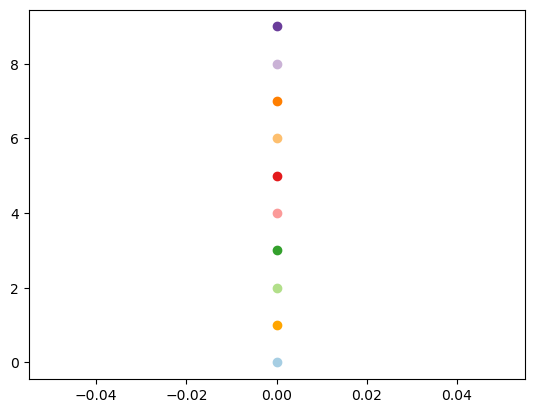

In [87]:
i = 0
for hpvGene in hpvGeneColor:
    plt.scatter(0,i,color = hpvGeneColor[hpvGene])
    i += 1

In [88]:
pave_hpvDic

{'E1': [['865', '2814']],
 'E2': [['2756', '3853']],
 'E5_ALPHA': [['3850', '4101']],
 'E6': [['104', '559']],
 'E7': [['562', '858']],
 'L1': [['5639', '7156']],
 'L2': [['4237', '5658']],
 'E1^E4': [['865', '880'], ['3358', '3620']],
 'URR': [['7157', '7906'], ['1', '103']]}

In [42]:
# clusterPlotRecode = []
# i = 0
# for each in CLdf['Ins']:
#     chro = CLdf['Chro'][i]
#     if chro != 'X' and chro != 'Y':
#         clusterPlotRecode += [sum(chromsLength[0:int(chro)-1])+ each ]
#     elif chro == 'X':
#         clusterPlotRecode += [sum(chromsLength[0:22-1])+ each]
#     elif chro == 'Y':
#         clusterPlotRecode += [sum(chromsLength[0:23-1])+ each]
#     i+=1
# CLdf['recodeIns'] = clusterPlotRecode

In [91]:
clusterPlotRecode = []
i = 0
for each in plot_1_info_df['Ins']:
    chro = plot_1_info_df['Chro'][i]
    if chro != 'X' and chro != 'Y':
        clusterPlotRecode += [sum(chromsLength[0:int(chro)-1])+ each ]
    elif chro == 'X':
        clusterPlotRecode += [sum(chromsLength[0:22-1])+ each]
    elif chro == 'Y':
        clusterPlotRecode += [sum(chromsLength[0:23-1])+ each]
    i+=1
plot_1_info_df['recodeIns'] = clusterPlotRecode

In [44]:
# clusterPlotRecode = []
# i = 0
# for each in Tissuedf['Ins']:
#     chro = Tissuedf['Chro'][i]
#     if chro != 'X' and chro != 'Y':
#         clusterPlotRecode += [sum(chromsLength[0:int(chro)-1])+ each ]
#     elif chro == 'X':
#         clusterPlotRecode += [sum(chromsLength[0:22-1])+ each]
#     elif chro == 'Y':
#         clusterPlotRecode += [sum(chromsLength[0:23-1])+ each]
#     i+=1
# Tissuedf['recodeIns'] = clusterPlotRecode

In [92]:
plot_1_info_df[plot_1_info_df['Chro'] == '9']

,SampleID,SeqID,Chro,Ins,SPCov,hpvIns,Conf,numIns,GeneFallInto,GeneWithin50k,hpvGene,recodeIns
29,115294,Sample_115294,9,91025175,0.505488,6739;,high;,17,NaN,ENST00000653201;ENST00000655868;ENST0000066156...,L1;,1627514087
30,115294,Sample_115294,9,91169787,1.782509,6824;,high;,17,ENST00000430315;ENST00000667274;LINC00484,LINC00484;ENST00000686463;ENST00000667274;ENST...,L1;,1627658699
31,115294,Sample_115294,9,91180894,0.026605,2026;1923;,high;low;,17,ENST00000667274;LINC00484,LINC00484;ENST00000686463;ENST00000667274;ENST...,E1;E1;,1627669806
32,115294,Sample_115294,9,91181039,87.662206,2026;1923;,high;low;,17,ENST00000667274;LINC00484,LINC00484;ENST00000686463;ENST00000667274;ENST...,E1;E1;,1627669951
33,115294,Sample_115294,9,91181227,0.026605,2026;1333;,high;low;,17,ENST00000667274;LINC00484,LINC00484;ENST00000686463;ENST00000667274;ENST...,E1;E1;,1627670139
...,...,...,...,...,...,...,...,...,...,...,...,...
294,152-CB-46,Sample_152-CB-46,9,136925600,13.762558,2790;,high;,11,TRAF2,PTGDS;ENST00000569497;MIR4479;ENST00000395082;...,E1;E2;,1673414512
295,152-CB-46,Sample_152-CB-46,9,136944298,4.796043,503;,high;,11,FBXW5,PTGDS;ENST00000569497;LCNL1;ENST00000395082;FB...,E6;,1673433210
426,SOP-021,Sample_2920-CB-83,9,123319363,0.499898,1767;,high;,7,NaN,CRB2,E1;,1659808275
427,SOP-021,Sample_2920-CB-83,9,123319477,0.514959,1767;,high;,7,NaN,CRB2,E1;,1659808389


In [93]:
sum(chromsLength)

3088269832

In [95]:
sum(chromsLength[0:24])

3088269832

0 0
1 248956422
2 491149951
3 689445510
4 879660065
5 1061198324
6 1232004303
7 1391350276
8 1536488912
9 1674883629
10 1808681051
11 1943767673
12 2077042982
13 2191407310
14 2298451028
15 2400442217
16 2490780562
17 2574038003
18 2654411288
19 2713028904
20 2777473071
21 2824183054
22 2875001522
23 3031042417
24 3088269832


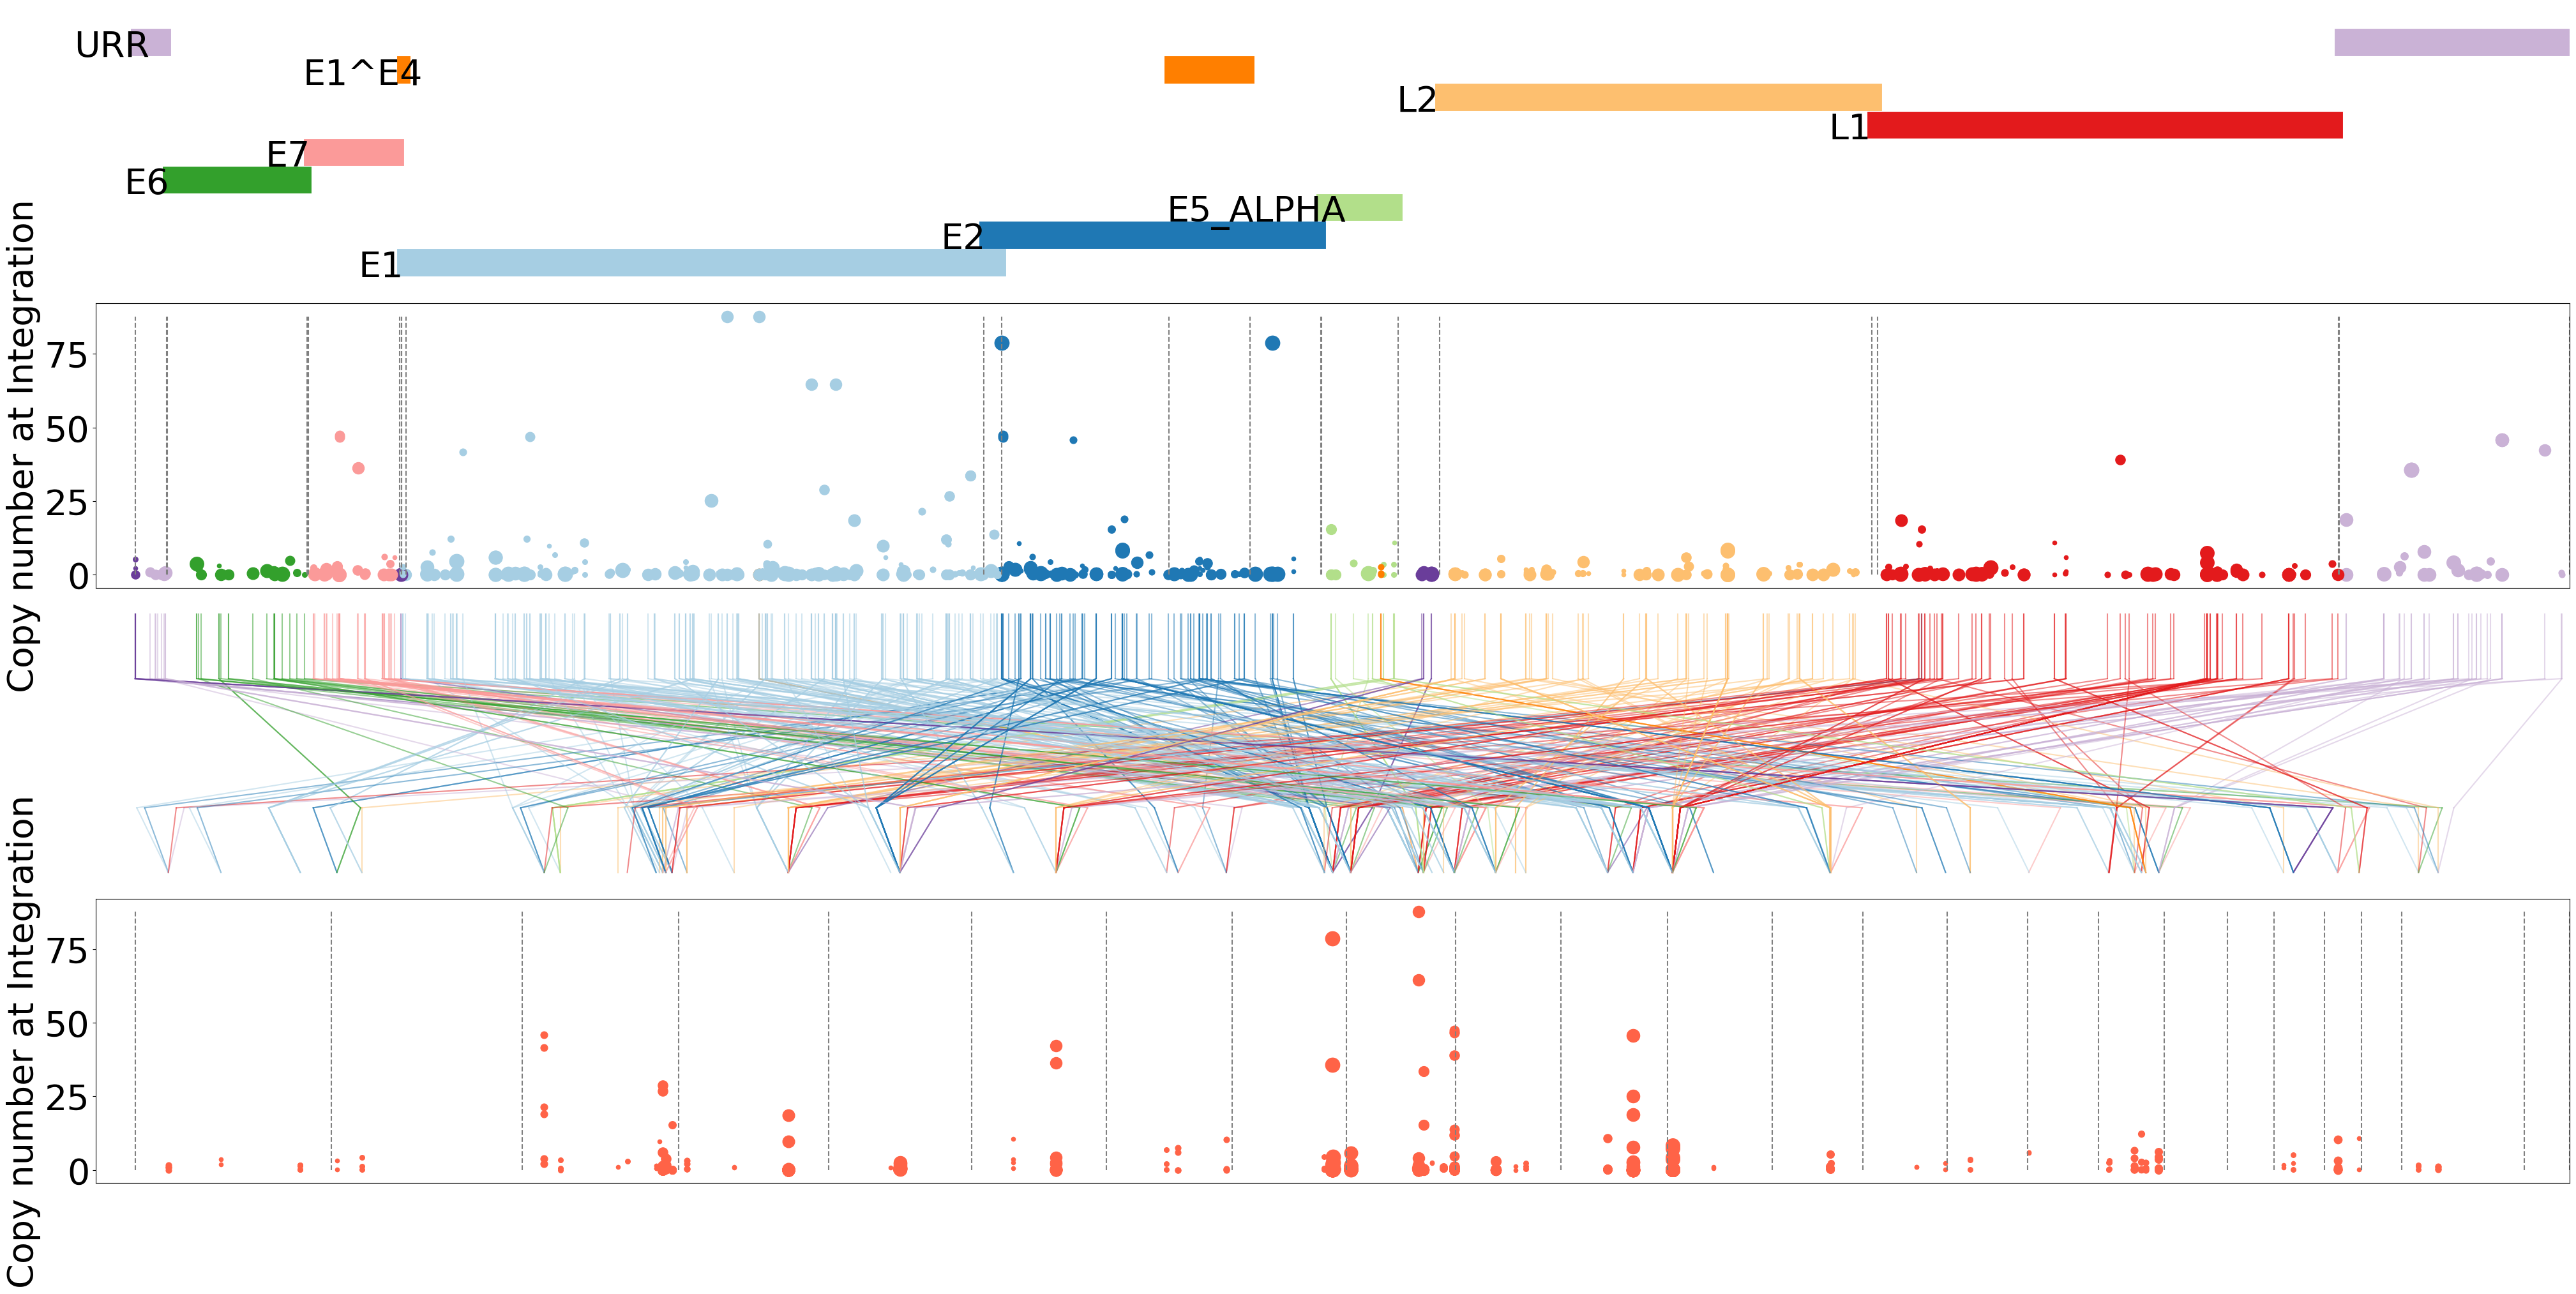

In [155]:
fig = plt.figure(figsize = [50,30])
gs = fig.add_gridspec(10, 8, hspace=0.1,wspace = 0.5)
plt.rcParams['font.size'] = '40'
#hum panel
ax1 = fig.add_subplot(gs[6:8, 0:10])
ylist = []
# i = 0
# for each in CLdf['recodeIns']:
#     x = each
#     y = CLdf['SPCov'][i]
#     ylist.append(y)
#     #print(x,y,CLdf['numIns'][i])
#     ax1.scatter(x,y,s = 10*CLdf['numIns'][i],color = 'tomato')
    
#     i += 1
# i = 0
# for each in Tissuedf['recodeIns']:
#     x = each
#     y = Tissuedf['SPCov'][i]
#     ylist.append(y)
#     #print(x,y,CLdf['numIns'][i])
#     ax1.scatter(x,y,s = 10*CLdf['numIns'][i],color = 'tomato')
    
    
#     i += 1
i = 0
for each in plot_1_info_df['recodeIns']:
    x = each
    y = plot_1_info_df['SPCov'][i]
    ylist.append(y)
    #print(x,y,size)
    ax1.scatter(x,y,s = 10*plot_1_info_df['numIns'][i],color = 'tomato')
    
    i += 1    
for i in range(0,25):
    ax1.vlines(x = sum(chromsLength[0:i]),ymin = 0,ymax = max(ylist),linestyle = 'dashed',color = 'grey')
    print(i,sum(chromsLength[0:i]))
ax1.ticklabel_format(style='plain')
ax1.set_xlim(-50000000,sum(chromsLength[0:24]))    
ax1.set_xticks([])
ax1.set_ylabel('Copy number at Integration')
#virus panel        
ax2 = fig.add_subplot(gs[2:4, 0:10])
xlist = []
ylist = []
# i = 0
# for each in CLdf['hpvIns']:
#     j = 0
#     for hpvIns in each.split(';'):
#         if hpvIns != '':
#             x = int(hpvIns)
#             y = CLdf['SPCov'][i]
#             xlist.append(x)
#             ylist.append(y)
#             #print(x,y,size)
#             hpvGene = CLdf['hpvGene'][i].split(';')[j]
#             ax2.scatter(x,y,s = 10*CLdf['numIns'][i],color = hpvGeneColor[hpvGene])
            
#         j+=1
#     i+=1
# i = 0
# for each in Tissuedf['hpvIns']:
#     j = 0
#     for hpvIns in each.split(';'):
#         if hpvIns != '':
#             x = int(hpvIns)
#             y = Tissuedf['SPCov'][i]
#             xlist.append(x)
#             ylist.append(y)
#             #print(x,y,size)
#             hpvGene = Tissuedf['hpvGene'][i].split(';')[j]
#             ax2.scatter(x,y,s = 10*Tissuedf['numIns'][i],color = hpvGeneColor[hpvGene])
            
#         j+=1
#     i+=1
i = 0
for each in plot_1_info_df['hpvIns']:
    j = 0
    for hpvIns in each.split(';'):
        if hpvIns != '':
            x = int(hpvIns)
            y = plot_1_info_df['SPCov'][i]
            xlist.append(x)
            ylist.append(y)
            #print(x,y,size)
            hpvGene = plot_1_info_df['hpvGene'][i].split(';')[j]
            ax2.scatter(x,y,s = 10*plot_1_info_df['numIns'][i],color = hpvGeneColor[hpvGene])
            
        j+=1
    i+=1

for gene in pave_hpvDic:
    for slot in pave_hpvDic[gene]:
        ax2.vlines(x = int(slot[0]),ymin = 0,ymax = max(ylist),linestyle = 'dashed',color = 'grey')
        ax2.vlines(x = int(slot[1]),ymin = 0,ymax = max(ylist),linestyle = 'dashed',color = 'grey')
#ax2.ticklabel_format(style='plain')
ax2.set_xlim(-50000000/sum(chromsLength[0:24])*7906,7906)
ax2.set_xticks([])
offsetDic = {}
i = 1
hpvOrder = ['E1','E2','E1^E4','E5_ALPHA','L2','L1','URR','E6','E7','Intergenic']
for gene in hpvOrder:
    if i < 5:
        offsetDic[gene] = -(5-i)*1000000
    else:
        offsetDic[gene] = (i-5)*1000000
    i += 1
ax2.set_ylabel('Copy number at Integration')
#link panel
ax3 = fig.add_subplot(gs[4:6, 0:10])
# i = 0
# for each in CLdf['recodeIns']:
#     j = 0
#     for hpvIns in CLdf['hpvIns'][i].split(';'):
#         if hpvIns != '':
#             hpvGene = CLdf['hpvGene'][i].split(';')[j]
#             ax3.plot([each+ 10*offsetDic[hpvGene],int(hpvIns)*sum(chromsLength[0:24])/7906],[2,6],color = hpvGeneColor[hpvGene],alpha = 0.5)
#             #print(each[0]+np.random.rand(1)[0]*10000)
#             ax3.plot([each ,each+ 10*offsetDic[hpvGene]],[0,2],color = hpvGeneColor[hpvGene],alpha = 0.5)
#             ax3.plot([int(hpvIns)*sum(chromsLength[0:24])/7906,int(hpvIns)*sum(chromsLength[0:24])/7906],[6,8],color = hpvGeneColor[hpvGene],alpha = 0.5)
#         j+=1
#     i+=1
i = 0
for each in plot_1_info_df['recodeIns']:
    j = 0
    for hpvIns in plot_1_info_df['hpvIns'][i].split(';'):
        if hpvIns != '':
            hpvGene = plot_1_info_df['hpvGene'][i].split(';')[j]
            ax3.plot([each+ 10*offsetDic[hpvGene],int(hpvIns)*sum(chromsLength[0:24])/7906],[2,6],color = hpvGeneColor[hpvGene],alpha = 0.5)
            #print(each[0]+np.random.rand(1)[0]*10000)
            ax3.plot([each ,each+ 10*offsetDic[hpvGene]],[0,2],color = hpvGeneColor[hpvGene],alpha = 0.5)
            ax3.plot([int(hpvIns)*sum(chromsLength[0:24])/7906,int(hpvIns)*sum(chromsLength[0:24])/7906],[6,8],color = hpvGeneColor[hpvGene],alpha = 0.5)
        j+=1
    i+=1
        
            
ax3.set_xlim(-50000000,sum(chromsLength[0:24]))
ax3.set_xticks([])
ax3.set_yticks([])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)

#virus reference panel
ax4 = fig.add_subplot(gs[0:2, 0:10])
i = 0        
for hpvGene in pave_hpvDic:
    xlist = []
    for slot in pave_hpvDic[hpvGene]:
        x = int(slot[0])
        xlist.append(x)
        step = 10
        space = 5
        y = 0 + i*step + i*space
        end = int(slot[1])
        rect = patches.Rectangle((x,y),end-x,step,linewidth=10,edgecolor=hpvGeneColor[hpvGene],\
                                 facecolor=hpvGeneColor[hpvGene])
        ax4.add_patch(rect)
    #ax4.legend(hpvGeneColor.keys())
    ax4.text(min(xlist) - 20-60*len(hpvGene),y - space/2,hpvGene)
    
    i += 1
ax4.set_xlim(-50000000/sum(chromsLength[0:24])*7906,7906)
ax4.set_ylim(0-10,y + space + step + 10)
ax4.set_xticks([])
ax4.set_yticks([])
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
plt.savefig('link_plot_all_sample_v3.pdf')
plt.margins(x=1)
#plt.tight_layout()
plt.show()


In [189]:
#distribution of type2 HPV integrations
hpvGeneList = []
for each in plot_1_info_df['hpvGene']:
    hpvGeneList += each.split(';')
# for each in CLdf['hpvGene']:
#     hpvGeneList += each.split(';')
# for each in Tissuedf['hpvGene']:
#     hpvGeneList += each.split(';')
hpvGeneList = [x for x in hpvGeneList if x!='']
countDic = dict(Counter(hpvGeneList))

In [190]:
countDic 

{'E2': 99,
 'E1': 178,
 'L1': 74,
 'E6': 19,
 'Intergenic': 11,
 'E7': 31,
 'URR': 39,
 'E1^E4': 30,
 'L2': 70,
 'E5_ALPHA': 17}

In [191]:
totSite = 0
for each in countDic:
    totSite += countDic[each]
hpvLenDic = {}
totLen = 0
for site in pave_hpvDic:
    hpvLen = 0
    for each in pave_hpvDic[site]:
        hpvLen += int(each[1])-int(each[0])
    hpvLenDic[site] = hpvLen
    totLen += hpvLen
expectHPV = {}
for each in hpvLenDic:
    prob = hpvLenDic[each]/totLen
    expectCount = round(totSite*prob)
    expectHPV[each] = expectCount

In [192]:
countDfHPV = pd.DataFrame.from_dict(countDic,orient='index')
expectHPVDf = pd.DataFrame.from_dict(expectHPV,orient = 'index')
countDfHPV = pd.DataFrame.merge(countDfHPV,expectHPVDf,left_index = True,right_index=True)
countDfHPV.columns = ['observed','expected']
countDfHPV = countDfHPV.sort_index()

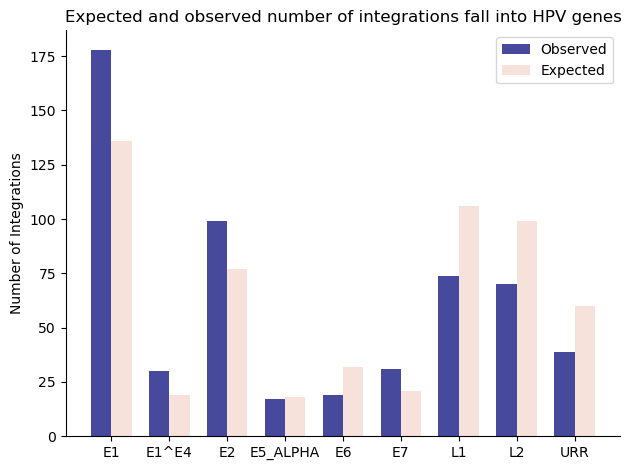

In [193]:
plt.rcParams['font.size'] = '10'
labels = list(countDfHPV.sort_index().index)
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, countDfHPV['observed'], width, label='Observed',color = '#46499c')
rects2 = ax.bar(x + width/2, countDfHPV['expected'], width, label='Expected',color = '#f7e2db')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Integrations')
ax.set_title('Expected and observed number of integrations fall into HPV genes')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.savefig('DNA_dup_freq_plot_1.pdf')
plt.show()

In [106]:
#chi square test
data = [countDfHPV['observed'], countDfHPV['expected']]
stat, p, dof, expected = chi2_contingency(data)

In [107]:
countDfHPV

,observed,expected
E2,99,77
E1,178,136
L1,74,106
E6,19,32
E7,31,21
URR,39,60
E1^E4,30,19
L2,70,99
E5_ALPHA,17,18


In [108]:
p

0.00013388044787234117

In [109]:
for i in range(0,9):
    data = [[countDfHPV['observed'][i],sum(countDfHPV['observed'][0:i])+sum(countDfHPV['observed'][i+1:])], [countDfHPV['expected'][i],sum(countDfHPV['expected'][0:i])+sum(countDfHPV['expected'][i+1:])]]
    stat, p, dof, expected = chi2_contingency(data)
    print(countDfHPV.index[i],p)

E2 0.06220905808310246
E1 0.0033970306195401927
L1 0.017404142084840136
E6 0.09927421333897755
E7 0.17694499950705866
URR 0.04517272207388985
E1^E4 0.12581984169588425
L2 0.027899593582606446
E5_ALPHA 1.0


In [110]:
#E2
data = [[155,sum(countDfHPV['observed'][1:])], [122,sum(countDfHPV['expected'][1:])]]
stat, p, dof, expected = chi2_contingency(data)
p

0.02886274405390309

In [111]:
#E1
data = [[249,countDfHPV['observed'][0]+sum(countDfHPV['observed'][2:])], [218,countDfHPV['expected'][0]+sum(countDfHPV['expected'][1:])]]
stat, p, dof, expected = chi2_contingency(data)
p

2.921528241753608e-06

In [112]:
#L1
data = [[161,sum(countDfHPV['observed'][0:2])+sum(countDfHPV['observed'][3:])], [169,sum(countDfHPV['expected'][0:2])+sum(countDfHPV['expected'][3:])]]
stat, p, dof, expected = chi2_contingency(data)
p

0.5074789114558114

In [113]:
#E6
data = [[161,sum(countDfHPV['observed'][0:3])+sum(countDfHPV['observed'][3:])], [122,sum(countDfHPV['expected'][0:2])+sum(countDfHPV['expected'][3:])]]
stat, p, dof, expected = chi2_contingency(data)
p

0.5488673773537636

In [121]:
#extract Type 1 integrations HPV16+ OPSCC
sup_0_HPV16 = pd.read_excel('../sup_1/Sup_table_0_all_samples_final.xlsx',sheet_name = 'HPV16 integration')

In [122]:
sup_0_HPV16

,ID,SeqID_Tumor,HPV type,Num HPV Integration,HPV integration,HPV integration breakpoints on HPV genome,Total # Host Genes with integration,Host Genes with integration,Integrated in at least 1 human gene,Integrated in at least 1 human cancer gene (COSMIC Teir1/2),Integrated in at least 1 human cancer gene (COSMIC Teir1/2); Gene Name,At least 1 integration is a type2 structure,# of E2 Breakpoints
0,3947,83022,HPV16,0,NaN,NaN,0,NaN,False,False,NaN,False,0
1,3963,83024,HPV16,0,NaN,NaN,0,NaN,False,False,NaN,False,0
2,3968,83026,HPV16,9,chr3:54562145;chr12:91944711;chr3:93470774;chr...,"893;4700,1149;6791,7405;4184;6584;4925;6791,74...",8,"CACNA2D3;;;;COL14A1;ENST00000534275,DLG2;;LINC...",True,False,;;;;;;;;,False,0
3,3979,83028,HPV16,0,NaN,NaN,0,NaN,False,False,NaN,False,0
4,3983,83030,HPV16,9,chr8:3990025;chr8:3866216;chr14:106781925;chr1...,2128;3233;2249;4357;3916;2480;4414;2480;1347,3,CSMD1;CSMD1;;SORCS3;;;LINC02346;;,True,False,;;;;;;;;,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,VA74,6670-CB-75,HPV16,20,chr4:137958671;chr11:27409717;chr7:2092566;chr...,2972;1421;4667;5671;7161;5663;4399;940;5567;59...,28,"ENST00000655176;LGR4;MAD1L1,ENST00000651235;;D...",True,False,;;;;;;;;;;;;;;;;;;;,False,3
242,5037,6670-CB-77,HPV16,205,chr12:25084502;chr9:116978499;chr5:7371447;chr...,7270;7239;2178;2178;1573;4395;973;7270;941;537...,215,IRAG2;ASTN2;ENST00000513219;ENST00000513219;EW...,True,True,;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;LEF1;;;;;;;;;;;;...,True,18
243,4854,6670-CB-83,HPV16,323,chr1:77367484;chr4:28657339;chr6:56637091;chr1...,4204;5316;4184;888;7561;1278;4184;465;6074;925...,250,"AK5;;DST;ENST00000548576,LINC02388,ENST0000054...",True,True,;;;;;;;;;;;;;;DCC;;;;;;;;;;;;;;;;;;;;;;;;;DNM2...,False,12
244,4945,6670-CB-84,HPV16,3,chr6:119283579;chr3:30681172;chr20:48440466,903;3297;3506,2,MAN1A1;TGFBR2;,True,True,;TGFBR2;,False,2


In [127]:
plot_2_df = sup_0[(sup_0['HPV type '] == 'HPV16') & (sup_0['Site'] == 'OP') & (sup_0['HPV integration type']!='Type2')]

In [135]:
plot_2_df = plot_2_df.merge(sup_0_HPV16,on='SeqID_Tumor')

In [140]:
plot_2_df['HPV integration breakpoints on HPV genome']

0      893;4700,1149;6791,7405;4184;6584;4925;6791,74...
1           2128;3233;2249;4357;3916;2480;4414;2480;1347
2                               6989;1434;5453,1937;1433
3      996;6874;6264;7239;5778;7116;3913;5060;972;980...
4                                    2159;2110;1400;1344
                             ...                        
126                                                 4200
127    2972;1421;4667;5671;7161;5663;4399;940;5567;59...
128    4204;5316;4184;888;7561;1278;4184;465;6074;925...
129                                        903;3297;3506
130                                            1387;7846
Name: HPV integration breakpoints on HPV genome, Length: 131, dtype: object

In [195]:
#distribution of type2 HPV integrations
import re
hpvGeneList = []
for each in plot_2_df['HPV integration breakpoints on HPV genome']:
    if pd.notna(each):
        for ins in re.split(';|,',str(each)):
            for gene in pave_hpvDic:
                for slot in pave_hpvDic[gene]:
                    if int(ins) > int(slot[0]) and int(ins) < int(slot[1]):
                        hpvGeneList+=[gene]
        
# for each in CLdf['hpvGene']:
#     hpvGeneList += each.split(';')
# for each in Tissuedf['hpvGene']:
#     hpvGeneList += each.split(';')
hpvGeneList = [x for x in hpvGeneList if x!='']
countDic = dict(Counter(hpvGeneList))

In [196]:
pave_hpvDic

{'E1': [['865', '2814']],
 'E2': [['2756', '3853']],
 'E5_ALPHA': [['3850', '4101']],
 'E6': [['104', '559']],
 'E7': [['562', '858']],
 'L1': [['5639', '7156']],
 'L2': [['4237', '5658']],
 'E1^E4': [['865', '880'], ['3358', '3620']],
 'URR': [['7157', '7906'], ['1', '103']]}

In [197]:
countDic

{'E1': 792,
 'L2': 228,
 'L1': 208,
 'URR': 170,
 'E2': 151,
 'E5_ALPHA': 97,
 'E1^E4': 66,
 'E6': 30,
 'E7': 23}

In [198]:
totSite = 0
for each in countDic:
    totSite += countDic[each]
hpvLenDic = {}
totLen = 0
for site in pave_hpvDic:
    hpvLen = 0
    for each in pave_hpvDic[site]:
        hpvLen += int(each[1])-int(each[0])
    hpvLenDic[site] = hpvLen
    totLen += hpvLen
expectHPV = {}
for each in hpvLenDic:
    prob = hpvLenDic[each]/totLen
    expectCount = round(totSite*prob)
    expectHPV[each] = expectCount
countDfHPV = pd.DataFrame.from_dict(countDic,orient='index')
expectHPVDf = pd.DataFrame.from_dict(expectHPV,orient = 'index')
countDfHPV = pd.DataFrame.merge(countDfHPV,expectHPVDf,left_index = True,right_index=True)
countDfHPV.columns = ['observed','expected']
countDfHPV = countDfHPV.sort_index()

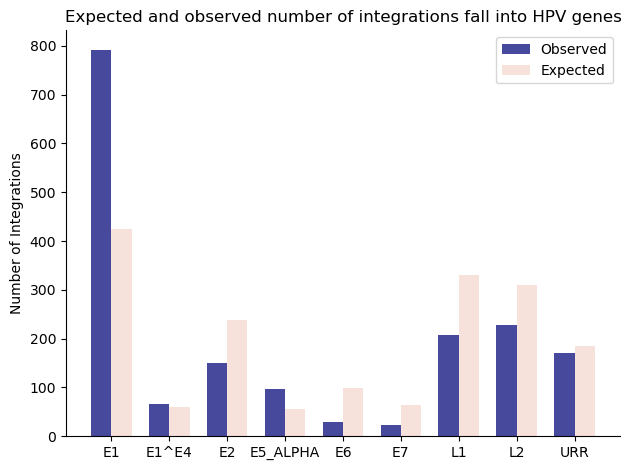

In [199]:
plt.rcParams['font.size'] = '10'
labels = list(countDfHPV.sort_index().index)
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, countDfHPV['observed'], width, label='Observed',color = '#46499c')
rects2 = ax.bar(x + width/2, countDfHPV['expected'], width, label='Expected',color = '#f7e2db')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Integrations')
ax.set_title('Expected and observed number of integrations fall into HPV genes')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.savefig('DNA_dup_freq_plot_2.pdf')
plt.show()

In [200]:
for i in range(0,9):
    data = [[countDfHPV['observed'][i],sum(countDfHPV['observed'][0:i])+sum(countDfHPV['observed'][i+1:])], [countDfHPV['expected'][i],sum(countDfHPV['expected'][0:i])+sum(countDfHPV['expected'][i+1:])]]
    stat, p, dof, expected = chi2_contingency(data)
    print(countDfHPV.index[i],p)

E1 1.2419587053922458e-38
E1^E4 0.6501135483061617
E2 2.9974305337811435e-06
E5_ALPHA 0.0006750039330603267
E6 1.0636469480808827e-09
E7 1.410027893410622e-05
L1 1.4590034696815513e-08
L2 0.00017741037821990838
URR 0.4333437769464249
